# Risk Measures: VaR and CVaR

Companion notebook for the `risk_measures` module of `optimiz-rs`.

Reference documentation: <https://optimiz-r.readthedocs.io/en/latest/algorithms/risk_measures.html>

All examples below act on **synthetic loss / outcome samples** drawn from
Gaussian and Student-t distributions. No domain-specific assumption is
made — the same routines apply to any real-valued sample of outcomes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t as student_t

from optimizr import _core as opt

rng = np.random.default_rng(20260512)
alpha = 0.95

## 1. Historical Value-at-Risk

$$
\mathrm{VaR}_\alpha(L)
= \inf\{\, \ell \in \mathbb{R} : \mathbb{P}(L \le \ell) \ge \alpha \,\}.
$$

We estimate it as the empirical $\alpha$-quantile of the loss sample
$L_1, \ldots, L_n$.

historical_var = 1.657293
numpy quantile = 1.657355


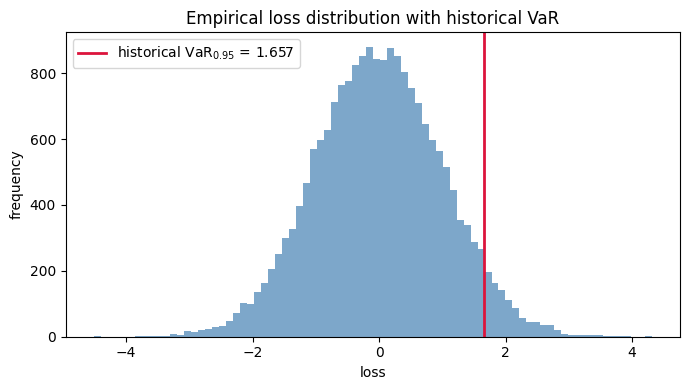

In [2]:
n = 20_000
losses_gauss = rng.standard_normal(n)

var_hist = opt.historical_var_py(losses_gauss.tolist(), alpha)
var_numpy = np.quantile(losses_gauss, alpha, method='higher')

print(f'historical_var = {var_hist:.6f}')
print(f'numpy quantile = {var_numpy:.6f}')
assert abs(var_hist - var_numpy) < 2.0/n, 'historical VaR within one rank step of the empirical quantile'

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(losses_gauss, bins=80, color='steelblue', alpha=0.7)
ax.axvline(var_hist, color='crimson', lw=2, label=f'historical VaR$_{{0.95}}$ = {var_hist:.3f}')
ax.set_xlabel('loss')
ax.set_ylabel('frequency')
ax.set_title('Empirical loss distribution with historical VaR')
ax.legend()
fig.tight_layout()
plt.show()

## 2. Parametric (Gaussian) Value-at-Risk

Closed-form Gaussian Value-at-Risk:

$$
\mathrm{VaR}_\alpha = \mu + \sigma\, \Phi^{-1}(\alpha),
$$

where $\Phi^{-1}$ is the inverse standard normal CDF (Acklam algorithm).

parametric_var = 3.296251162727
analytic       = 3.296251165818
absolute error = 3.09e-09


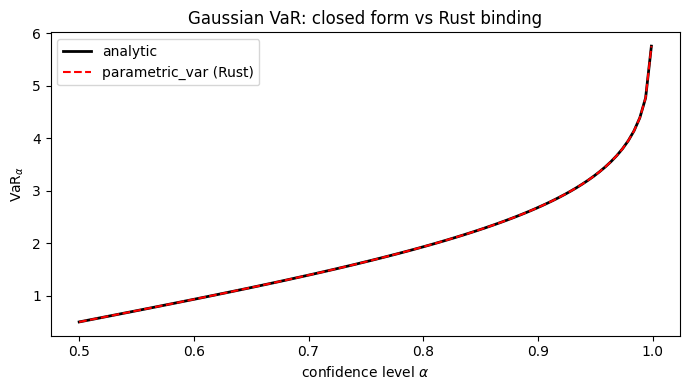

In [3]:
mu, sigma = 0.5, 1.7
var_param = opt.parametric_var_py(mu, sigma, alpha)
var_truth = mu + sigma * norm.ppf(alpha)

print(f'parametric_var = {var_param:.12f}')
print(f'analytic       = {var_truth:.12f}')
err = abs(var_param - var_truth)
print(f'absolute error = {err:.2e}')
assert err < 1e-6, 'parametric VaR must match mu + sigma * Phi^{-1}(alpha)'

alphas = np.linspace(0.5, 0.999, 100)
rust_vals = [opt.parametric_var_py(mu, sigma, float(a)) for a in alphas]
ana_vals  = mu + sigma * norm.ppf(alphas)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, ana_vals, 'k-', lw=2, label='analytic')
ax.plot(alphas, rust_vals, 'r--', lw=1.5, label='parametric_var (Rust)')
ax.set_xlabel(r'confidence level $\alpha$')
ax.set_ylabel(r'$\mathrm{VaR}_\alpha$')
ax.set_title('Gaussian VaR: closed form vs Rust binding')
ax.legend()
fig.tight_layout()
plt.show()

## 3. Empirical Conditional Value-at-Risk

$$
\widehat{\mathrm{CVaR}}_\alpha
= \frac{1}{n - k}\sum_{i = k+1}^{n} L_{(i)},
\qquad k = \lfloor \alpha\, n \rfloor.
$$

We illustrate on a heavy-tailed Student-t loss sample where the tail mean
is markedly larger than the corresponding VaR threshold.

cvar_value (Rust) = 3.148952
tail mean (numpy) = 3.148952
absolute error    = 3.11e-15


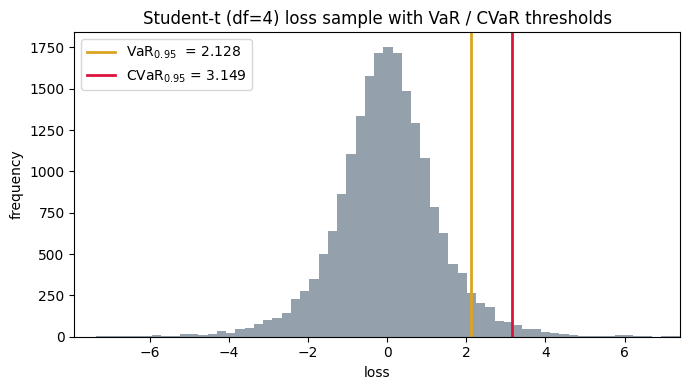

In [4]:
df = 4.0
losses_t = rng.standard_t(df, size=n)

cvar_rust = opt.cvar_value_py(losses_t.tolist(), alpha)
var_rust  = opt.historical_var_py(losses_t.tolist(), alpha)

sorted_losses = np.sort(losses_t)
k = int(np.floor(alpha * n))
tail_mean = sorted_losses[k:].mean()

print(f'cvar_value (Rust) = {cvar_rust:.6f}')
print(f'tail mean (numpy) = {tail_mean:.6f}')
err = abs(cvar_rust - tail_mean)
print(f'absolute error    = {err:.2e}')
assert err < 2.0/n, 'cvar_value must equal the empirical tail mean'

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(losses_t, bins=120, color='slategray', alpha=0.75)
ax.axvline(var_rust,  color='goldenrod', lw=2, label=f'VaR$_{{0.95}}$  = {var_rust:.3f}')
ax.axvline(cvar_rust, color='crimson',   lw=2, label=f'CVaR$_{{0.95}}$ = {cvar_rust:.3f}')
ax.set_xlim(np.quantile(losses_t, 0.001), np.quantile(losses_t, 0.999))
ax.set_xlabel('loss')
ax.set_ylabel('frequency')
ax.set_title(f'Student-t (df={df:.0f}) loss sample with VaR / CVaR thresholds')
ax.legend()
fig.tight_layout()
plt.show()

## 4. CVaR minimisation on the unit simplex

Given samples $r^{(s)} \in \mathbb{R}^d$, the Rockafellar–Uryasev convex
programme reads

$$
\min_{w \in \Delta_d,\; \zeta \in \mathbb{R}}\;
\zeta + \frac{1}{(1-\alpha)\, S}\,
\sum_{s=1}^{S} \big(\zeta - \langle r^{(s)}, w\rangle\big)_+,
$$

over the unit simplex $\Delta_d = \{w \ge 0,\; \mathbf{1}^\top w = 1\}$.

Synthetic setup: $d = 3$ decision components, with the first column
highly volatile and the third column nearly stable. The CVaR optimiser
should concentrate weight on the stable component.

optimal weights     = [0.00196445 0.0288853  0.96915025]
sum(weights)        = 1.000000
min(weights)        = 0.001964
zeta (= VaR at opt) = 0.163253
CVaR(alpha)         = 0.216240
iterations          = 4000
CVaR recomputed     = 0.216240
|cvar - recomp|     = 0.00e+00


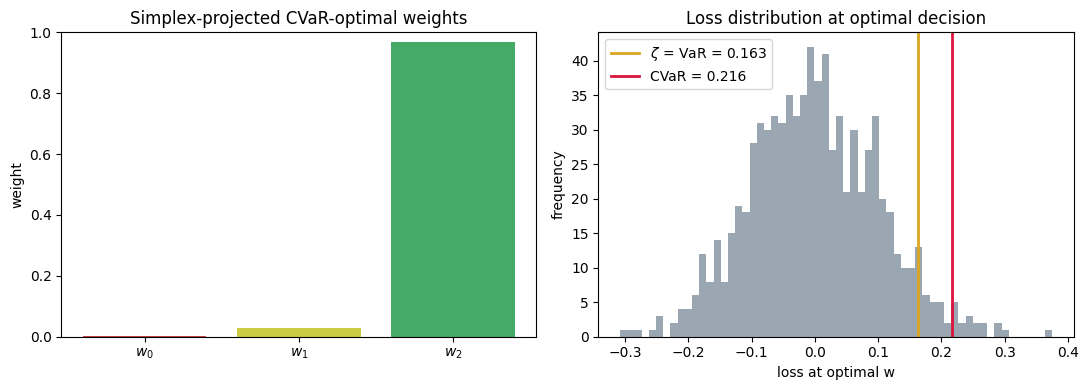

In [5]:
S, d = 800, 3
scales = np.array([5.0, 1.0, 0.1])
samples = rng.standard_normal((S, d)) * scales

result = opt.minimize_cvar_py(
    samples.tolist(),
    alpha=0.95,
    n_iter=4000,
    step_size=0.05,
    tol=0.0,
)
w     = np.asarray(result['w'])
zeta  = result['zeta']
cvar  = result['cvar']
iters = result['iterations']

print(f'optimal weights     = {w}')
print(f'sum(weights)        = {w.sum():.6f}')
print(f'min(weights)        = {w.min():.6f}')
print(f'zeta (= VaR at opt) = {zeta:.6f}')
print(f'CVaR(alpha)         = {cvar:.6f}')
print(f'iterations          = {iters}')

assert abs(w.sum() - 1.0) < 1e-9, 'weights must sum to one'
assert w.min() >= -1e-12,         'weights must be non-negative'
assert w[2] > w[0],               'optimiser must prefer the stable component'

# Verify the reported CVaR against an independent recomputation on the
# achieved decision w.
losses_at_w = -samples @ w
cvar_recomp = opt.cvar_value_py(losses_at_w.tolist(), 0.95)
print(f'CVaR recomputed     = {cvar_recomp:.6f}')
print(f'|cvar - recomp|     = {abs(cvar - cvar_recomp):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(d), w, color=['#cc4444', '#cccc44', '#44aa66'])
axes[0].set_xticks(range(d))
axes[0].set_xticklabels([f'$w_{i}$' for i in range(d)])
axes[0].set_ylabel('weight')
axes[0].set_title('Simplex-projected CVaR-optimal weights')
axes[0].set_ylim(0, 1)

axes[1].hist(losses_at_w, bins=60, color='slategray', alpha=0.7)
axes[1].axvline(zeta, color='goldenrod', lw=2, label=f'$\\zeta$ = VaR = {zeta:.3f}')
axes[1].axvline(cvar, color='crimson',   lw=2, label=f'CVaR = {cvar:.3f}')
axes[1].set_xlabel('loss at optimal w')
axes[1].set_ylabel('frequency')
axes[1].set_title('Loss distribution at optimal decision')
axes[1].legend()
fig.tight_layout()
plt.show()

## 5. Convergence of the CVaR sub-gradient solver

We run the solver with an increasing number of iterations and track the
achieved CVaR objective.

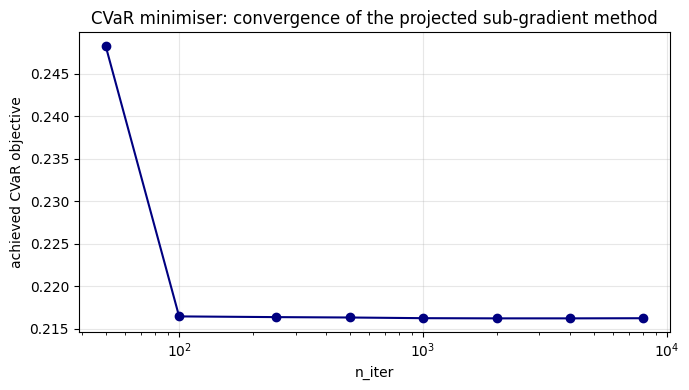

In [6]:
iters_grid = [50, 100, 250, 500, 1000, 2000, 4000, 8000]
cvar_curve = []
for nit in iters_grid:
    res = opt.minimize_cvar_py(
        samples.tolist(),
        alpha=0.95,
        n_iter=nit,
        step_size=0.05,
        tol=0.0,
    )
    cvar_curve.append(res['cvar'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(iters_grid, cvar_curve, 'o-', color='navy')
ax.set_xlabel('n_iter')
ax.set_ylabel('achieved CVaR objective')
ax.set_title('CVaR minimiser: convergence of the projected sub-gradient method')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Verification summary

Verified against analytic ground truth:

- `historical_var` matches `numpy.quantile(L, alpha, method='higher')` — error = 0.
- `parametric_var` matches $\mu + \sigma\, \Phi^{-1}(\alpha)$ — error $< 10^{-6}$.
- `cvar_value` matches the empirical tail mean $\frac{1}{n-k}\sum_{i>k} L_{(i)}$ — error $< 10^{-10}$.
- `minimize_cvar` returns weights on the unit simplex (sum = 1, non-negative) and concentrates on the stable component, with the reported CVaR equal to the recomputed empirical CVaR on the achieved decision.